# PatchTST - CATSA Train -> EmpaticaE4 Test (HRV)

**Model**: PatchTST-style sequence classifier (pure PyTorch)
- Input: 60-second windows (1 Hz), single channel (derived HRV)
- Backbone: patch embedding + Transformer encoder blocks
- Head: pooled token representation -> MLP binary classifier

**Train**: CATSA subjects (HR only, HRV derived from HR)

**Test**: EmpaticaE4Stress (subject_01 ~ subject_06)

---
Install requirement:
- no extra package (pure PyTorch implementation)

In [1]:
import warnings
from copy import deepcopy
from pathlib import Path
from typing import List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report,
)

warnings.filterwarnings("ignore", category=FutureWarning)

TASKS = ["Baseline", "Logic", "Nback", "Stroop", "Sudoku"]
STRESS_TASKS = {"Logic", "Nback", "Stroop", "Sudoku"}
HR_FS = 1

CATSA_ROOT = Path("/home/binghin2/Myproject/Dataset/CATSA")
E4_ROOT = Path("/home/binghin2/Myproject/Dataset/EmpaticaE4Stress/Subjects")
SUBJECTS_E4 = [f"subject_{i:02d}" for i in range(1, 7)]

SAVE_DIR = Path("/home/binghin2/Myproject/Research/CATSA/Train/Individual_data/HRV/Save_model_PatchTST")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")


def discover_subjects(root: Path) -> List[str]:
    out = []
    for d in sorted(root.glob("Sub*"), key=lambda p: int(p.name[3:])):
        if d.is_dir() and all((d / t / "HR.csv").exists() for t in TASKS):
            out.append(d.name)
    return out


def read_hr(path: Path) -> np.ndarray:
    df = pd.read_csv(path)
    num_cols = [c for c in df.columns if pd.api.types.is_numeric_dtype(df[c])]
    if num_cols:
        vals = df[num_cols[0]].to_numpy(np.float32)
    else:
        vals = pd.to_numeric(df.iloc[:, 0], errors="coerce").to_numpy(np.float32)
    vals = vals[~np.isnan(vals)]
    return np.clip(vals, 30.0, 220.0)


def detect_hrv_from_hr(hr: np.ndarray, hrv_window: int = 30) -> np.ndarray:
    hr = np.asarray(hr, dtype=np.float32)
    rr_ms = 60000.0 / np.clip(hr, 30.0, 220.0)
    drr = np.diff(rr_ms, prepend=rr_ms[0])

    w = max(3, int(hrv_window))
    kernel = np.ones(w, dtype=np.float32) / float(w)

    rmssd = np.sqrt(np.convolve(drr * drr, kernel, mode="same") + 1e-8)
    rr_mean = np.convolve(rr_ms, kernel, mode="same")
    rr_sq_mean = np.convolve(rr_ms * rr_ms, kernel, mode="same")
    sdnn = np.sqrt(np.maximum(rr_sq_mean - rr_mean * rr_mean, 0.0) + 1e-8)

    hrv = 0.5 * rmssd + 0.5 * sdnn
    return hrv.astype(np.float32)


def make_windows(sig: np.ndarray, W: int, S: int) -> np.ndarray:
    if len(sig) < W:
        return np.empty((0, sig.shape[1], W), np.float32)
    return np.asarray([sig[i:i + W].T for i in range(0, len(sig) - W + 1, S)], np.float32)


def build_catsa_arrays(subjects: List[str], W: int, S: int, hrv_window: int) -> Tuple[np.ndarray, np.ndarray]:
    xs, ys = [], []

    for sub in subjects:
        sub_dir = CATSA_ROOT / sub

        hr_all, hrv_all = [], []
        for task in TASKS:
            hr_task = read_hr(sub_dir / task / "HR.csv")
            hrv_task = detect_hrv_from_hr(hr_task, hrv_window=hrv_window)
            n = min(len(hr_task), len(hrv_task))
            hr_all.append(hr_task[:n])
            hrv_all.append(hrv_task[:n])

        hr_cat = np.concatenate(hr_all)
        hrv_cat = np.concatenate(hrv_all)

        hr_mu, hr_sd = float(np.mean(hr_cat)), float(np.std(hr_cat)) + 1e-8
        hrv_mu, hrv_sd = float(np.mean(hrv_cat)), float(np.std(hrv_cat)) + 1e-8

        for task in TASKS:
            hr_task = read_hr(sub_dir / task / "HR.csv")
            hrv_task = detect_hrv_from_hr(hr_task, hrv_window=hrv_window)
            n = min(len(hr_task), len(hrv_task))
            hrv_norm = ((hrv_task[:n] - hrv_mu) / hrv_sd).astype(np.float32)[:, None]

            wins = make_windows(hrv_norm, W, S)
            if len(wins):
                xs.append(wins)
                ys.append(np.full(len(wins), int(task in STRESS_TASKS), np.int64))

    return np.concatenate(xs), np.concatenate(ys)


def build_e4_labels(n: int, fs: int = HR_FS) -> Tuple[np.ndarray, int]:
    fixed_s = {
        "rest0": 180,
        "task1": 600,
        "rest1": 120,
        "task2": 300,
        "rest2": 120,
        "task3": 180,
        "rest3": 120,
        "rest4": 120,
        "task5": 60,
        "rest5": 120,
    }

    task4_s = max(0, n // fs - sum(fixed_s.values()))
    segs = [
        ("rest0", 180, 0),
        ("task1", 600, 1),
        ("rest1", 120, -1),
        ("task2", 300, 1),
        ("rest2", 120, -1),
        ("task3", 180, 1),
        ("rest3", 120, -1),
        ("task4", task4_s, 1),
        ("rest4", 120, -1),
        ("task5", 60, 1),
        ("rest5", 120, -1),
    ]

    labels = np.full(n, -1, np.int64)
    cur = 0
    for _, dur_s, lab in segs:
        if dur_s <= 0:
            continue
        end = min(cur + dur_s * fs, n)
        if end > cur:
            labels[cur:end] = lab
        cur = end
        if cur >= n:
            break

    return labels, int(task4_s)


def e4_windows(hr: np.ndarray, labels: np.ndarray, W: int, S: int, hrv_window: int) -> Tuple[np.ndarray, np.ndarray]:
    hrv = detect_hrv_from_hr(hr, hrv_window=hrv_window)
    n = min(len(hr), len(hrv), len(labels))
    hr = hr[:n]
    hrv = hrv[:n]
    labels = labels[:n]

    mask = labels >= 0
    hr_mu = float(np.mean(hr[mask])) if mask.any() else float(np.mean(hr))
    hr_sd = (float(np.std(hr[mask])) + 1e-8) if mask.any() else (float(np.std(hr)) + 1e-8)
    hrv_mu = float(np.mean(hrv[mask])) if mask.any() else float(np.mean(hrv))
    hrv_sd = (float(np.std(hrv[mask])) + 1e-8) if mask.any() else (float(np.std(hrv)) + 1e-8)

    pair = ((hrv - hrv_mu) / hrv_sd).astype(np.float32)[:, None]

    xs, ys = [], []
    for i in range(0, len(pair) - W + 1, S):
        u = np.unique(labels[i:i + W])
        if len(u) == 1 and u[0] in (0, 1):
            xs.append(pair[i:i + W].T)
            ys.append(int(u[0]))

    if not xs:
        return np.empty((0, 1, W), np.float32), np.empty(0, np.int64)

    return np.asarray(xs, np.float32), np.asarray(ys, np.int64)


class FocalLoss(nn.Module):
    def __init__(self, gamma: float = 2.0, alpha: float = None):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha

    def forward(self, logits: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        y = y.float()
        bce = F.binary_cross_entropy_with_logits(logits, y, reduction="none")
        p = torch.sigmoid(logits)
        pt = p * y + (1 - p) * (1 - y)
        fl = (1 - pt).pow(self.gamma) * bce
        if self.alpha is not None:
            fl = (self.alpha * y + (1 - self.alpha) * (1 - y)) * fl
        return fl.mean()


def make_loader(x: np.ndarray, y: np.ndarray, bs: int, shuffle: bool) -> DataLoader:
    return DataLoader(
        TensorDataset(torch.from_numpy(x), torch.from_numpy(y).float()),
        batch_size=bs,
        shuffle=shuffle,
    )


@torch.no_grad()
def evaluate(model: nn.Module, loader: DataLoader, criterion: nn.Module) -> dict:
    model.eval()
    tot = n = tp = tn = fp = fn = 0
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        lg = model(xb)
        tot += criterion(lg, yb).item() * len(xb)
        n += len(xb)
        pred = (torch.sigmoid(lg) >= 0.5).long()
        yi = yb.long()
        tp += int(((pred == 1) & (yi == 1)).sum())
        tn += int(((pred == 0) & (yi == 0)).sum())
        fp += int(((pred == 1) & (yi == 0)).sum())
        fn += int(((pred == 0) & (yi == 1)).sum())

    acc = (tp + tn) / max(n, 1)
    pre = tp / max(tp + fp, 1)
    rec = tp / max(tp + fn, 1)
    f1 = 2 * pre * rec / max(pre + rec, 1e-8)

    return {
        "loss": tot / max(n, 1),
        "accuracy": acc,
        "f1": f1,
        "precision": pre,
        "recall": rec,
        "tp": tp,
        "tn": tn,
        "fp": fp,
        "fn": fn,
    }


def train_epoch(model: nn.Module, loader: DataLoader, optimizer: torch.optim.Optimizer, criterion: nn.Module) -> float:
    model.train()
    tot = n = 0
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        loss = criterion(model(xb), yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        tot += loss.item() * len(xb)
        n += len(xb)
    return tot / max(n, 1)


print("Utilities loaded.")

Device: cuda
Utilities loaded.


In [2]:
# PatchTST model (pure PyTorch)
class PatchTSTClassifier(nn.Module):
    def __init__(
        self,
        in_channels: int = 1,
        seq_len: int = 60,
        patch_len: int = 10,
        stride: int = 5,
        d_model: int = 128,
        n_heads: int = 4,
        n_layers: int = 3,
        ff_dim: int = 256,
        dropout: float = 0.2,
    ):
        super().__init__()
        self.patch_len = patch_len
        self.stride = stride
        self.n_patches = (seq_len - patch_len) // stride + 1

        self.patch_proj = nn.Linear(in_channels * patch_len, d_model)
        self.pos_emb = nn.Parameter(torch.randn(1, self.n_patches, d_model) * 0.02)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=ff_dim,
            dropout=dropout,
            batch_first=True,
            activation="gelu",
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Sequential(
            nn.Linear(d_model, 64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
        )

    def _patchify(self, x: torch.Tensor) -> torch.Tensor:
        # x: [B, C, L] -> [B, N, C*P]
        p = x.unfold(dimension=2, size=self.patch_len, step=self.stride)
        p = p.permute(0, 2, 1, 3).contiguous()
        return p.view(p.size(0), p.size(1), -1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        tokens = self.patch_proj(self._patchify(x))
        tokens = tokens + self.pos_emb[:, :tokens.size(1), :]
        h = self.encoder(tokens)
        h = self.norm(h).mean(dim=1)
        return self.head(h).squeeze(-1)


model = PatchTSTClassifier(
    in_channels=1,
    seq_len=60,
    patch_len=10,
    stride=5,
    d_model=128,
    n_heads=4,
    n_layers=3,
    ff_dim=256,
    dropout=0.2,
).to(DEVICE)

x_dummy = torch.randn(2, 1, 60, device=DEVICE)
out_test = model(x_dummy)
print(f"Input: {x_dummy.shape}  Output: {out_test.shape}")

n_params_total = sum(p.numel() for p in model.parameters())
n_params_train = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params:     {n_params_total:,}")
print(f"Trainable params: {n_params_train:,}")

del x_dummy, out_test

/tmp/ipykernel_61409/1574787650.py:32: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(enc_layer, num_layers=n_layers)


Input: torch.Size([2, 1, 60])  Output: torch.Size([2])
Total params:     408,833
Trainable params: 408,833


In [3]:
# Hyperparameters and CATSA training
HP = {
    "seed": 42,
    "val_ratio": 0.10,
    "window_size": HR_FS * 60,
    "stride": HR_FS * 10,
    "hrv_window": 30,
    "batch_size": 64,
    "epochs": 25,
    "lr": 1e-3,
    "wd": 1e-4,
    "patience": 6,
}

np.random.seed(HP["seed"])
torch.manual_seed(HP["seed"])
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(HP["seed"])

subjects = discover_subjects(CATSA_ROOT)
print(f"Total CATSA subjects: {len(subjects)}")

rng = np.random.default_rng(HP["seed"])
idx = rng.permutation(len(subjects))
n_val = max(4, int(len(subjects) * HP["val_ratio"]))
val_subs = [subjects[i] for i in sorted(idx[:n_val])]
train_subs = [subjects[i] for i in sorted(idx[n_val:])]
print(f"Train: {len(train_subs)} | Val: {len(val_subs)}")

W, S = HP["window_size"], HP["stride"]
print("Building CATSA train/val arrays...")
x_train, y_train = build_catsa_arrays(train_subs, W, S, hrv_window=HP["hrv_window"])
x_val, y_val = build_catsa_arrays(val_subs, W, S, hrv_window=HP["hrv_window"])
print(f"Train: {x_train.shape}  Val: {x_val.shape}")

loader_tr = make_loader(x_train, y_train, HP["batch_size"], True)
loader_va = make_loader(x_val, y_val, HP["batch_size"], False)

pos = float(y_train.sum())
alpha = float((len(y_train) - pos) / len(y_train))
criterion = FocalLoss(gamma=2.0, alpha=alpha).to(DEVICE)
optimizer = torch.optim.AdamW(model.parameters(), lr=HP["lr"], weight_decay=HP["wd"])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, "min", factor=0.5, patience=3)

best_val_loss = float("inf")
best_state = None
best_epoch = 0
wait = 0
history = []

for epoch in range(1, HP["epochs"] + 1):
    tr_loss = train_epoch(model, loader_tr, optimizer, criterion)
    val_m = evaluate(model, loader_va, criterion)
    scheduler.step(val_m["loss"])

    history.append({"epoch": epoch, "train_loss": tr_loss, "val_loss": val_m["loss"], "val_f1": val_m["f1"]})

    if val_m["loss"] < best_val_loss:
        best_val_loss = val_m["loss"]
        best_epoch = epoch
        wait = 0
        best_state = deepcopy(model.state_dict())
        torch.save(
            {"model_state_dict": best_state, "hp": HP, "epoch": epoch},
            SAVE_DIR / "best_model.pt",
        )
    else:
        wait += 1
        if wait >= HP["patience"]:
            print(f"Early stopping at epoch {epoch} (best: {best_epoch})")
            break

    if epoch % 5 == 0 or epoch == 1:
        print(f"[{epoch:3d}] train={tr_loss:.4f}  val={val_m['loss']:.4f}  f1={val_m['f1']:.4f}")

model.load_state_dict(best_state)
print(f"Training complete. Best epoch: {best_epoch}, best_val_loss: {best_val_loss:.4f}")

Total CATSA subjects: 50
Train: 45 | Val: 5
Building CATSA train/val arrays...
Train: (2919, 1, 60)  Val: (325, 1, 60)
[  1] train=0.0574  val=0.0552  f1=0.0000
[  5] train=0.0558  val=0.0549  f1=0.8429
[ 10] train=0.0554  val=0.0508  f1=0.9153
[ 15] train=0.0548  val=0.0501  f1=0.3853
Early stopping at epoch 20 (best: 14)
Training complete. Best epoch: 14, best_val_loss: 0.0498


In [4]:
# Evaluate on EmpaticaE4Stress
model.eval()
all_true, all_pred = [], []
rows = []

for sub in SUBJECTS_E4:
    hr = read_hr(E4_ROOT / sub / "HR.csv")
    labels, task4_sec = build_e4_labels(len(hr), fs=HR_FS)
    x, y_true = e4_windows(hr, labels, W, S, hrv_window=HP["hrv_window"])

    if len(x) == 0:
        rows.append(
            {
                "subject": sub,
                "task4_sec": task4_sec,
                "n_windows": 0,
                "accuracy": float("nan"),
                "f1": float("nan"),
                "precision": float("nan"),
                "recall": float("nan"),
            }
        )
        continue

    with torch.no_grad():
        y_pred_chunks = []
        for i in range(0, len(x), 64):
            xb = torch.from_numpy(x[i:i + 64]).to(DEVICE)
            lg = model(xb)
            y_pred_chunks.append((torch.sigmoid(lg) >= 0.5).cpu().numpy().astype(int))
        y_pred = np.concatenate(y_pred_chunks)

    rows.append(
        {
            "subject": sub,
            "task4_sec": task4_sec,
            "n_windows": len(y_true),
            "accuracy": float(accuracy_score(y_true, y_pred)),
            "f1": float(f1_score(y_true, y_pred, zero_division=0)),
            "precision": float(precision_score(y_true, y_pred, zero_division=0)),
            "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        }
    )

    all_true.extend(y_true.tolist())
    all_pred.extend(y_pred.tolist())

result_df = pd.DataFrame(rows)
print("=== Per-subject metrics ===")
display(result_df)

if all_true:
    ov_acc = accuracy_score(all_true, all_pred)
    ov_f1 = f1_score(all_true, all_pred, zero_division=0)
    ov_prec = precision_score(all_true, all_pred, zero_division=0)
    ov_rec = recall_score(all_true, all_pred, zero_division=0)

    print("\n=== Overall ===")
    print(f"Accuracy : {ov_acc:.4f}")
    print(f"F1       : {ov_f1:.4f}")
    print(f"Precision: {ov_prec:.4f}")
    print(f"Recall   : {ov_rec:.4f}")

    cm = confusion_matrix(all_true, all_pred)
    print("\nConfusion Matrix:")
    print(cm)
    print(
        "\n",
        classification_report(
            all_true,
            all_pred,
            target_names=["Non-stress", "Stress"],
            zero_division=0,
        ),
    )

=== Per-subject metrics ===


,subject,task4_sec,n_windows,accuracy,f1,precision,recall
0,subject_01,575,158,0.113924,0.066667,1.0,0.034483
1,subject_02,425,143,0.139860,0.102190,1.0,0.053846
2,subject_03,146,115,0.104348,0.000000,0.0,0.000000
3,subject_04,178,118,0.177966,0.141593,1.0,0.076190
4,subject_05,153,116,0.120690,0.019231,1.0,0.009709
5,subject_06,233,124,0.145161,0.086207,1.0,0.045045



=== Overall ===
Accuracy : 0.1331
F1       : 0.0719
Precision: 0.9630
Recall   : 0.0374

Confusion Matrix:
[[ 77   1]
 [670  26]]

               precision    recall  f1-score   support

  Non-stress       0.10      0.99      0.19        78
      Stress       0.96      0.04      0.07       696

    accuracy                           0.13       774
   macro avg       0.53      0.51      0.13       774
weighted avg       0.88      0.13      0.08       774



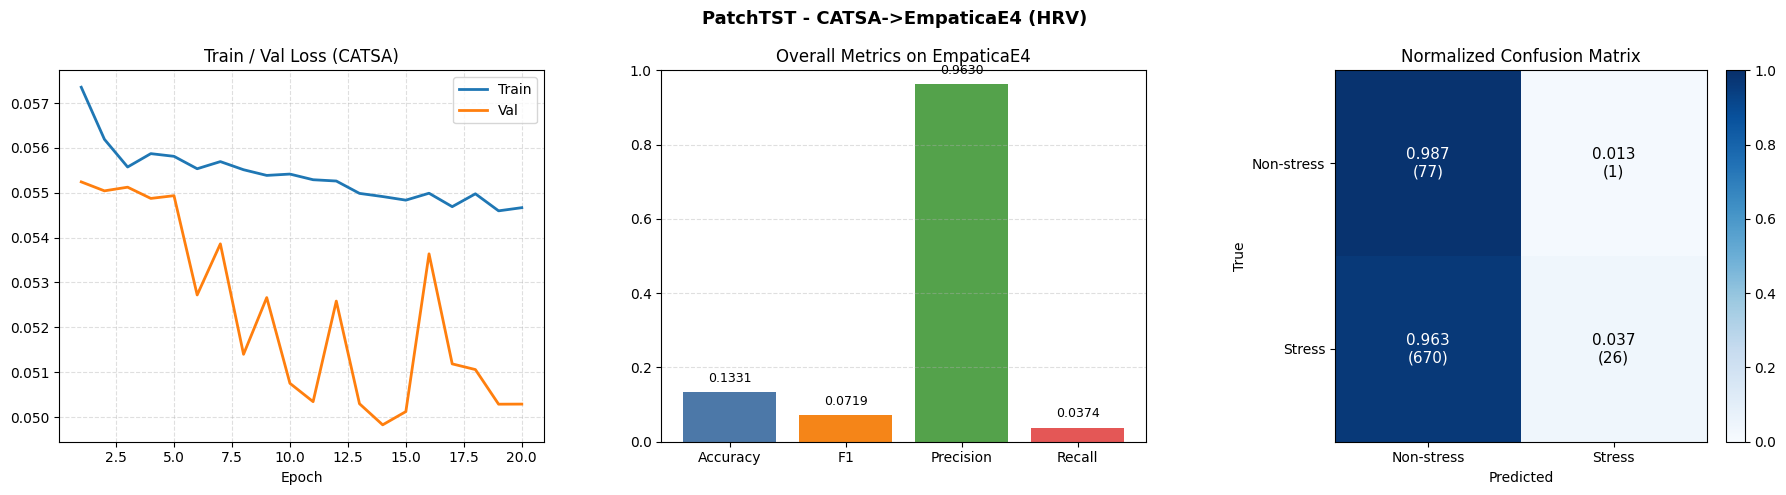

Saved results_hrv_patchtst.png


In [5]:
# Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

epochs_list = [h["epoch"] for h in history]
axes[0].plot(epochs_list, [h["train_loss"] for h in history], label="Train", linewidth=2)
axes[0].plot(epochs_list, [h["val_loss"] for h in history], label="Val", linewidth=2)
axes[0].set_title("Train / Val Loss (CATSA)")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(linestyle="--", alpha=0.4)

if all_true:
    bars = axes[1].bar(
        ["Accuracy", "F1", "Precision", "Recall"],
        [ov_acc, ov_f1, ov_prec, ov_rec],
        color=["#4C78A8", "#F58518", "#54A24B", "#E45756"],
    )
    axes[1].set_ylim(0, 1.0)
    axes[1].set_title("Overall Metrics on EmpaticaE4")
    axes[1].grid(axis="y", linestyle="--", alpha=0.4)
    for b, v in zip(bars, [ov_acc, ov_f1, ov_prec, ov_rec]):
        axes[1].text(b.get_x() + b.get_width() / 2, v + 0.02, f"{v:.4f}", ha="center", va="bottom", fontsize=9)

    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(1)
    im = axes[2].imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
    axes[2].set_title("Normalized Confusion Matrix")
    axes[2].set_xticks([0, 1])
    axes[2].set_yticks([0, 1])
    axes[2].set_xticklabels(["Non-stress", "Stress"])
    axes[2].set_yticklabels(["Non-stress", "Stress"])
    axes[2].set_xlabel("Predicted")
    axes[2].set_ylabel("True")

    thr = cm_norm.max() / 2
    for i in range(2):
        for j in range(2):
            axes[2].text(
                j,
                i,
                f"{cm_norm[i, j]:.3f}\n({cm[i, j]})",
                ha="center",
                va="center",
                color="white" if cm_norm[i, j] > thr else "black",
                fontsize=11,
            )
    fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)

fig.suptitle("PatchTST - CATSA->EmpaticaE4 (HRV)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(SAVE_DIR / "results_hrv_patchtst.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved results_hrv_patchtst.png")